<div style="text-align:left;">
    <span style="
        display:inline-block;
        background-color:#4169E1;
        color:white;
        padding:10px 20px;
        border-radius:8px;
        font-size:45px;
        font-weight:bold;
    ">
        SHapley Additive exPlanations for XGBoost
    </span>
</div>

**Author:** Sarra Chouk 

**Student ID:** 60300372

**Project:** EHR Mortality Risk Prediction  

**Dataset:** MIMIC-IV

**Date:** April 4, 2026  

---

### **Objective**
To build the explainability component for the saved XGBoost model using SHAP.

### **Setup and Library Imports**

In [15]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 12

from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

### **Define Artifact Paths**

In [2]:
MODEL_ARTIFACTS_DIR = Path("../artifacts/xgboost")
SHAP_OUTPUT_DIR = MODEL_ARTIFACTS_DIR / "shap_outputs"
SHAP_VISUALIZATIONS_DIR = Path("../artifacts/shap_visualizations")

SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SHAP_VISUALIZATIONS_DIR.mkdir(parents=True, exist_ok=True)

def save_shap_figure(filename, dpi=300):
    output_path = SHAP_VISUALIZATIONS_DIR / filename
    plt.gcf().savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {output_path.name}")
    return output_path

print("Model artifacts dir:", MODEL_ARTIFACTS_DIR.resolve())
print("SHAP output dir:", SHAP_OUTPUT_DIR.resolve())
print("SHAP visualization dir:", SHAP_VISUALIZATIONS_DIR.resolve())

Model artifacts dir: /Users/sarrachouk/Desktop/ehr-mortality-prediction/artifacts/xgboost_tuned_calibrated
SHAP output dir: /Users/sarrachouk/Desktop/ehr-mortality-prediction/artifacts/xgboost_tuned_calibrated/shap_outputs


### **Load Saved Model and Saved Datasets**

In [3]:
model = joblib.load(MODEL_ARTIFACTS_DIR / "xgb_model.joblib")
metadata = json.load(open(MODEL_ARTIFACTS_DIR / "metadata.json", "r", encoding="utf-8"))
best_threshold = metadata.get("best_threshold", 0.5)

feature_names = pd.read_csv(MODEL_ARTIFACTS_DIR / "feature_names.csv")["feature_names"].tolist()

X_test = pd.read_csv(MODEL_ARTIFACTS_DIR / "X_test_used.csv")
y_test = pd.read_csv(MODEL_ARTIFACTS_DIR / "y_test_used.csv").squeeze("columns")

X_deployment = pd.read_csv(MODEL_ARTIFACTS_DIR / "X_deployment_used.csv")
y_deployment = pd.read_csv(MODEL_ARTIFACTS_DIR / "y_deployment_used.csv").squeeze("columns")

X_background = pd.read_csv(MODEL_ARTIFACTS_DIR / "X_background_for_shap.csv")

print("Loaded objects successfully.\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("X_deployment:", X_deployment.shape)
print("y_deployment:", y_deployment.shape)
print("X_background:", X_background.shape)
print("Number of feature names:", len(feature_names))
print("Best threshold from metadata:", best_threshold)

Loaded objects successfully.

X_test: (83356, 49)
y_test: (83356,)
X_deployment: (82211, 49)
y_deployment: (82211,)
X_background: (200, 49)
Number of feature names: 49


### **Extract the Underlying XGBoost mMdel**

In [5]:
def unwrap_estimator(model_obj, max_depth=10):
    """
    Recursively unwrap model wrappers until we reach the actual base estimator.
    This handles:
    - CalibratedClassifierCV
    - sklearn FrozenEstimator
    - wrappers exposing estimator / base_estimator
    """
    current = model_obj

    for depth in range(max_depth):
        print(f"Unwrap step {depth}: {type(current)}")

        type_name = type(current).__name__

        if "XGBClassifier" in type_name:
            return current

        if hasattr(current, "calibrated_classifiers_"):
            calibrated_list = current.calibrated_classifiers_
            if len(calibrated_list) > 0:
                first_calibrator = calibrated_list[0]

                if hasattr(first_calibrator, "estimator"):
                    current = first_calibrator.estimator
                    continue

                if hasattr(first_calibrator, "base_estimator"):
                    current = first_calibrator.base_estimator
                    continue

        if hasattr(current, "estimator"):
            current = current.estimator
            continue

        if hasattr(current, "base_estimator"):
            current = current.base_estimator
            continue

        if hasattr(current, "_estimator"):
            current = current._estimator
            continue

        break

    raise ValueError(f"Could not unwrap to XGBClassifier. Final object type: {type(current)}")


base_model = unwrap_estimator(model)
print("\nFinal unwrapped base model type:", type(base_model))

Unwrap step 0: <class 'sklearn.calibration.CalibratedClassifierCV'>
Unwrap step 1: <class 'sklearn.frozen._frozen.FrozenEstimator'>
Unwrap step 2: <class 'xgboost.sklearn.XGBClassifier'>

Final unwrapped base model type: <class 'xgboost.sklearn.XGBClassifier'>


In [6]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_dep_proba = model.predict_proba(X_deployment)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 6))
print("Test PR-AUC:", round(average_precision_score(y_test, y_test_proba), 6))
print("Deployment ROC-AUC:", round(roc_auc_score(y_deployment, y_dep_proba), 6))
print("Deployment PR-AUC:", round(average_precision_score(y_deployment, y_dep_proba), 6))

Test ROC-AUC: 0.868265
Test PR-AUC: 0.177622
Deployment ROC-AUC: 0.870541
Deployment PR-AUC: 0.181535


### **Choose a Manageable SHAP Analysis Sample**

In [7]:
N_SHAP_SAMPLES = min(1000, len(X_test))
X_explain = X_test.sample(n=N_SHAP_SAMPLES, random_state=42).copy()
y_explain = y_test.loc[X_explain.index].copy()
y_explain_proba = model.predict_proba(X_explain)[:, 1]

print("X_explain shape:", X_explain.shape)

X_explain shape: (1000, 49)


### **Build SHAP Component**

In [8]:
explainer = shap.TreeExplainer(base_model)
shap_values_raw = explainer.shap_values(X_explain)
expected_value = explainer.expected_value

print("SHAP explainer created successfully.")
print("Expected value:", expected_value)

def standardize_shap_values(shap_values):
    """
    Return SHAP values as a 2D numpy array: [n_samples, n_features]
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            return np.array(shap_values[1])
        return np.array(shap_values[0])

    shap_values = np.array(shap_values)

    if shap_values.ndim == 3 and shap_values.shape[2] == 2:
        return shap_values[:, :, 1]

    return shap_values

shap_values = standardize_shap_values(shap_values_raw)

print("Standardized SHAP shape:", shap_values.shape)
assert shap_values.shape[0] == X_explain.shape[0]
assert shap_values.shape[1] == X_explain.shape[1]

if isinstance(expected_value, (list, np.ndarray)):
    expected_value_arr = np.array(expected_value)
    if expected_value_arr.ndim == 0:
        base_value = float(expected_value_arr)
    elif len(expected_value_arr) == 2:
        base_value = float(expected_value_arr[1])
    else:
        base_value = float(expected_value_arr.ravel()[0])
else:
    base_value = float(expected_value)

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.repeat(base_value, X_explain.shape[0]),
    data=X_explain.values,
    feature_names=X_explain.columns.tolist()
)

print("SHAP Explanation object created.")

SHAP explainer created successfully.
Expected value: -3.8491538
Standardized SHAP shape: (1000, 49)
SHAP Explanation object created.


### **Global SHAP Bar Plot**

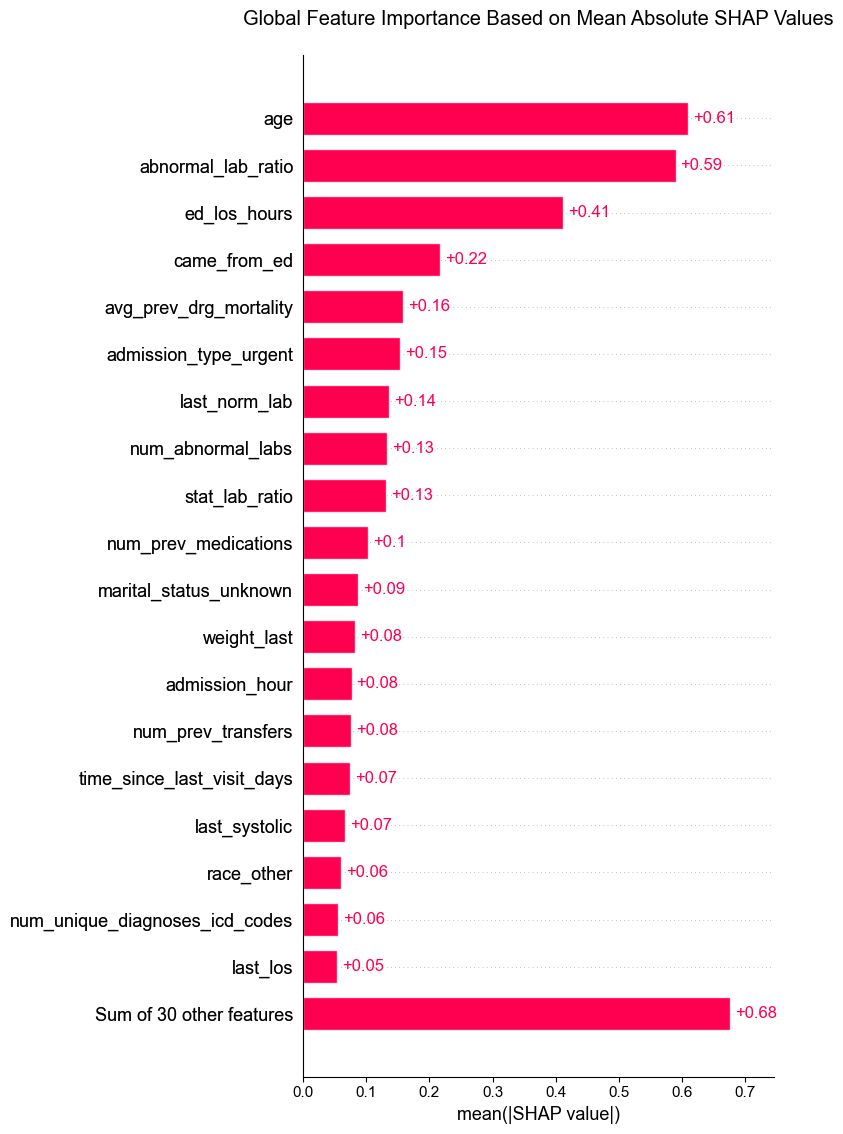

In [22]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title("Global Feature Importance Based on Mean Absolute SHAP Values\n")

plt.tight_layout()
save_shap_figure("shap_bar_top20.png")
plt.show()

### **SHAP Beeswarm Plot**

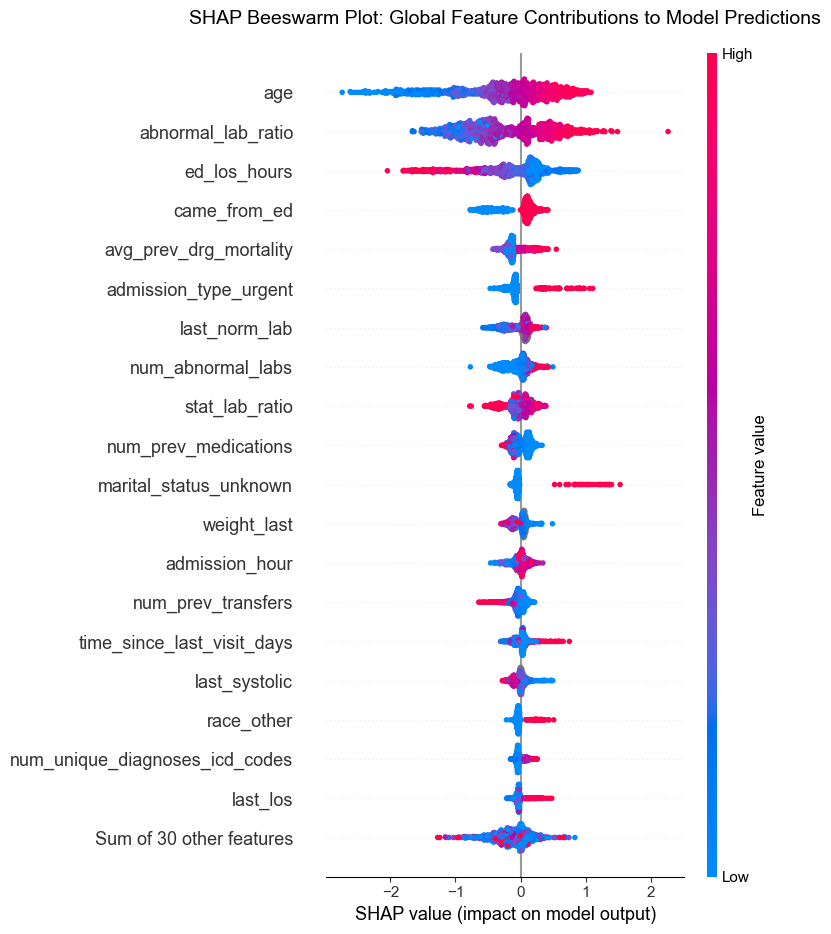

In [20]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("SHAP Beeswarm Plot: Global Feature Contributions to Model Predictions\n", fontsize=14)
plt.tight_layout()
save_shap_figure("shap_beeswarm_top20.png")
plt.show()

### **Select Local Cases to Explain**

In [23]:
# Use the saved model probabilities at the artifact's selected threshold.
threshold = best_threshold
pred_labels = (y_explain_proba >= threshold).astype(int)

local_cases_df = pd.DataFrame({
    "row_index": X_explain.index,
    "y_true": y_explain.values,
    "y_proba": y_explain_proba,
    "y_pred": pred_labels
}, index=X_explain.index)

local_cases_df = local_cases_df.sort_values("y_proba", ascending=False)

display(local_cases_df.head(10))

,row_index,y_true,y_proba,y_pred_05
47004,47004,1,0.973113,1
25007,25007,1,0.946038,1
42955,42955,0,0.934729,1
4788,4788,0,0.872547,1
69536,69536,1,0.859062,1
33354,33354,1,0.842680,1
16361,16361,1,0.767834,1
63507,63507,0,0.736818,1
25374,25374,1,0.710804,1
73651,73651,0,0.601513,1


### **SHAP Waterfall Plots**

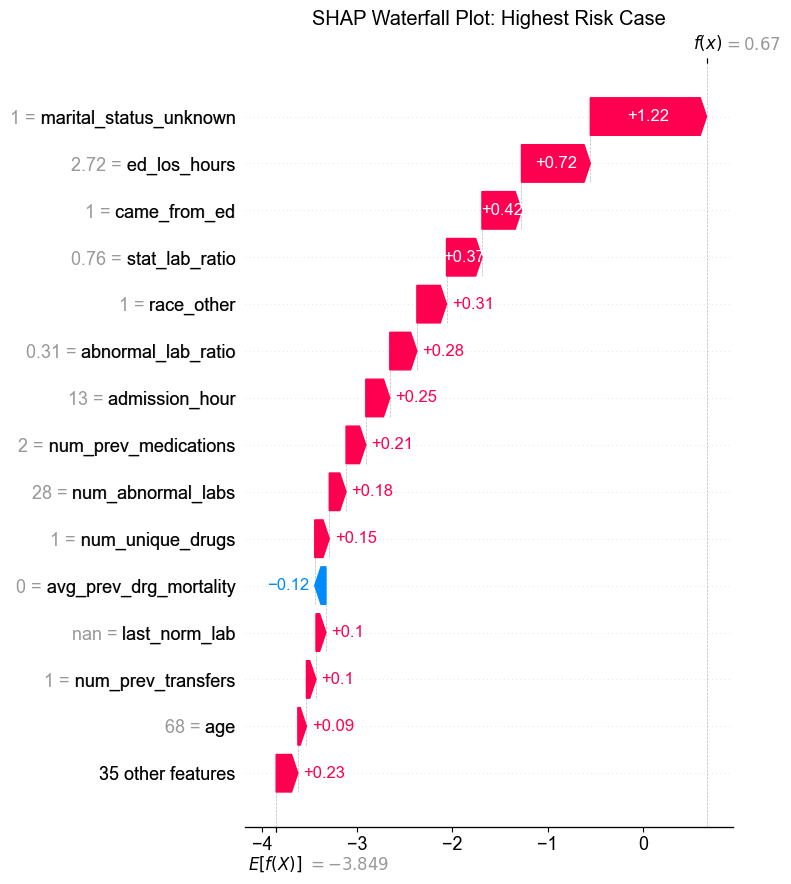

Saved waterfall plot for row 47004.0


In [28]:
def save_waterfall_for_index(row_idx, title_prefix, max_display=15):
    explain_position = X_explain.index.get_loc(row_idx)

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_explanation[explain_position], max_display=max_display, show=False)
    plt.title(f"SHAP Waterfall Plot: {title_prefix}")
    plt.tight_layout()
    safe_name = f"{title_prefix.lower().replace(' ', '_')}_row_{row_idx}.png"
    save_shap_figure(safe_name)
    plt.show()

    print(f"Saved waterfall plot for row {row_idx}")

top_risk_idx = local_cases_df.iloc[0]["row_index"]
save_waterfall_for_index(top_risk_idx, "Highest Risk Case")

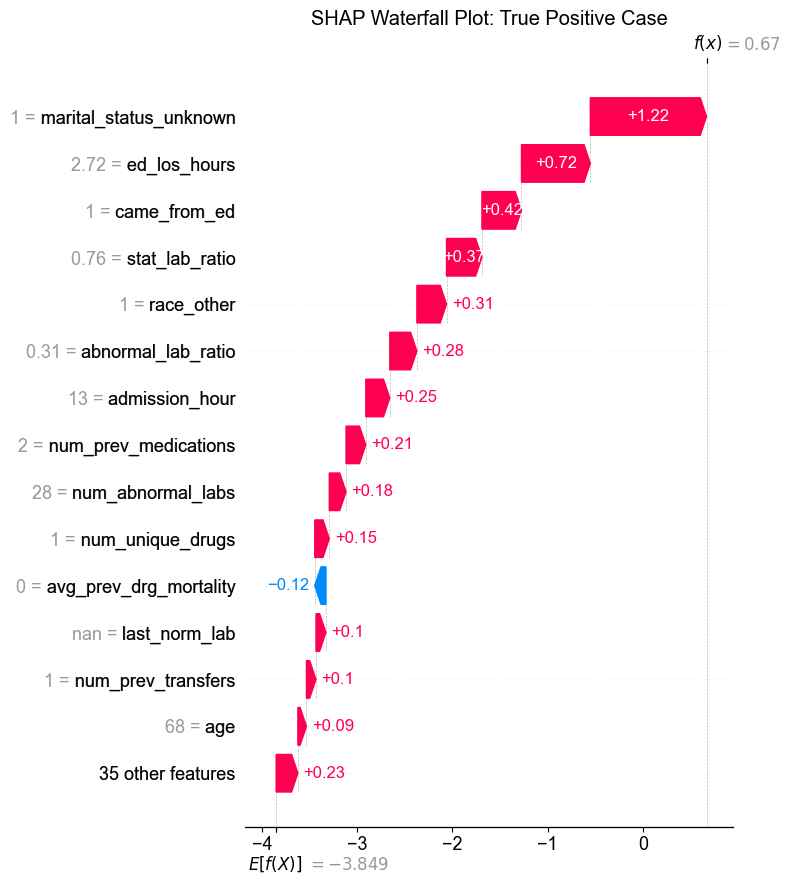

Saved waterfall plot for row 47004.0


In [32]:
tp_candidates = local_cases_df[
    (local_cases_df["y_true"] == 1) & (local_cases_df["y_pred"] == 1)
]

if len(tp_candidates) > 0:
    tp_idx = tp_candidates.iloc[0]["row_index"]
    save_waterfall_for_index(tp_idx, "True Positive Case")
else:
    print(f"No true positive found in the explained sample at threshold {threshold}.")

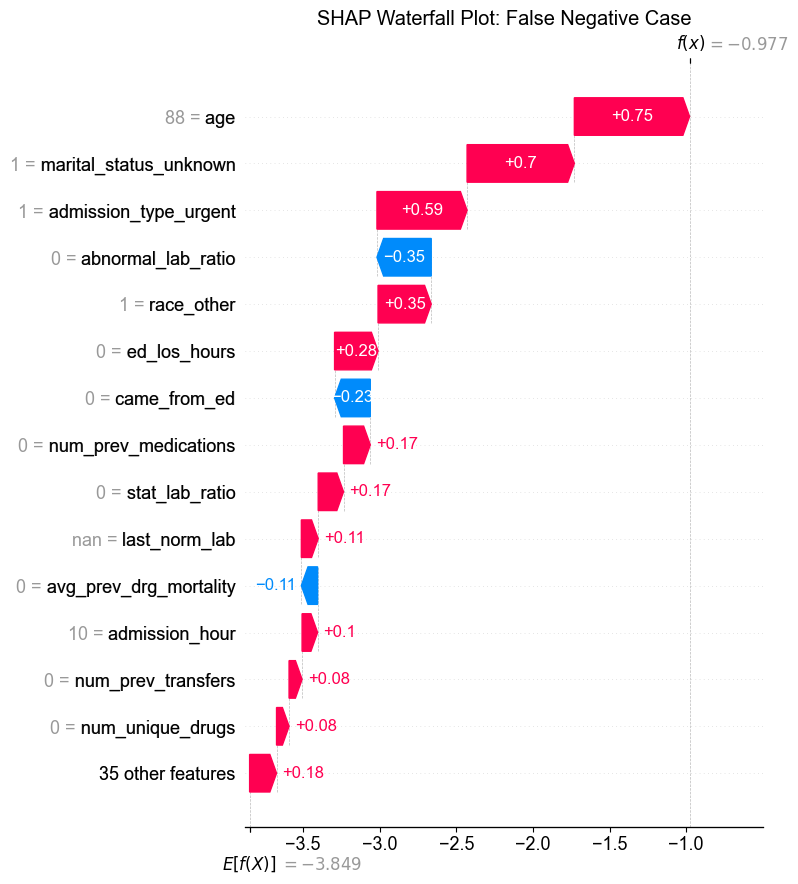

Saved waterfall plot for row 61832.0


In [29]:
fn_candidates = local_cases_df[
    (local_cases_df["y_true"] == 1) & (local_cases_df["y_pred"] == 0)
]

if len(fn_candidates) > 0:
    fn_idx = fn_candidates.iloc[0]["row_index"]
    save_waterfall_for_index(fn_idx, "False Negative Case")
else:
    print(f"No false negative found in the explained sample at threshold {threshold}.")

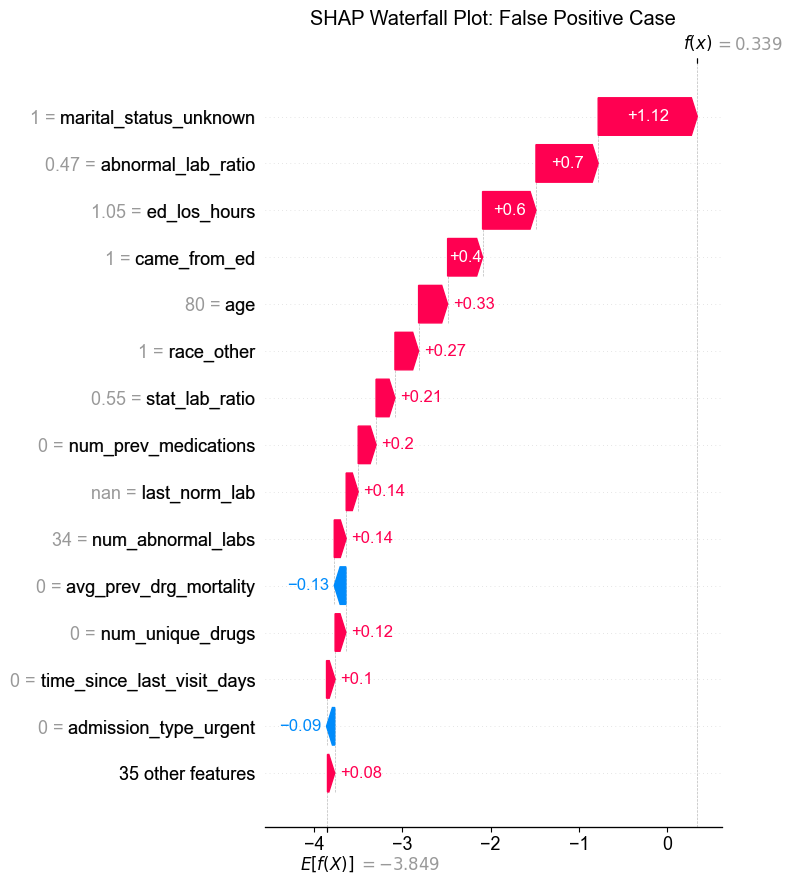

Saved waterfall plot for row 42955.0


In [30]:
fp_candidates = local_cases_df[
    (local_cases_df["y_true"] == 0) & (local_cases_df["y_pred"] == 1)
]

if len(fp_candidates) > 0:
    fp_idx = fp_candidates.iloc[0]["row_index"]
    save_waterfall_for_index(fp_idx, "False Positive Case")
else:
    print(f"No false positive found in the explained sample at threshold {threshold}.")

### **Save Summary and Metadata**

In [35]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

local_cases_df.to_csv(SHAP_OUTPUT_DIR / "local_cases_summary.csv", index=False)
print("Saved local case summary.")

shap_metadata = {
    "model_artifacts_dir": str(MODEL_ARTIFACTS_DIR),
    "shap_output_dir": str(SHAP_OUTPUT_DIR),
    "shap_visualizations_dir": str(SHAP_VISUALIZATIONS_DIR),
    "model_name": metadata.get("model_name"),
    "best_threshold": best_threshold,
    "n_background_rows": int(len(X_background)),
    "n_explained_rows": int(len(X_explain)),
    "top_10_features": global_importance_df["feature"].head(10).tolist()
}

with open(SHAP_OUTPUT_DIR / "shap_metadata.json", "w", encoding="utf-8") as f:
    json.dump(shap_metadata, f, indent=4)

print("Saved SHAP metadata.")

Saved local case summary.
Saved SHAP metadata.
